In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/project_3/uber_cleaned.xlsx')

In [ ]:
df.head()

,Row_ID,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,...,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,Datetime,Hour,DayOfWeek
0,0,2024-03-23,12:29:38,CNR5884300,No Driver Found,CID1982111,eBike,Palam Vihar,Jhilmil,NaN,...,0,NaN,NaN,NaN,NaN,NaN,NaN,2024-03-23 12:29:38,12,Saturday
1,1,2024-11-29,18:01:39,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,...,1,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI,2024-11-29 18:01:39,18,Friday
2,2,2024-08-23,08:56:10,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,...,0,NaN,627.0,13.58,4.9,4.9,Debit Card,2024-08-23 08:56:10,8,Friday
3,3,2024-10-21,17:17:25,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,...,0,NaN,416.0,34.02,4.6,5.0,UPI,2024-10-21 17:17:25,17,Monday
4,4,2024-09-16,22:08:00,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,...,0,NaN,737.0,48.21,4.1,4.3,UPI,2024-09-16 22:08:00,22,Monday


## Q1) What are the peak ride hours and days?

Business Objective: Identify demand peaks to optimize driver supply allocation (surge pricing windows, shift scheduling).

In [ ]:
hourly = df.groupby('Hour').size().reset_index(name='Total_Bookings')
hourly.sort_values('Total_Bookings', ascending=False).head(10)

,Hour,Total_Bookings
18,18,12397
19,19,11047
17,17,11044
16,16,9633
20,20,9630
10,10,9577
11,11,8390
9,9,8234
15,15,8202
21,21,8103


In [ ]:
daily = df.groupby('DayOfWeek').size().reset_index(name='Total_Bookings')
daily.sort_values('Total_Bookings', ascending=False)

,DayOfWeek,Total_Bookings
1,Monday,21644
2,Saturday,21542
6,Wednesday,21413
3,Sunday,21398
0,Friday,21397
5,Tuesday,21391
4,Thursday,21215


In [ ]:
completed_hourly = df[df['Booking Status']=='Completed'].groupby('Hour').size().reset_index(name='Completed_Rides')

# Merge to compare raw demand vs fulfilled demand by hour
hc = hourly.merge(completed_hourly, on='Hour', how='left')
hc['Fulfillment_Rate_%'] = (hc['Completed_Rides']/hc['Total_Bookings']*100).round(1)
hc.sort_values('Hour').head(10)

,Hour,Total_Bookings,Completed_Rides,Fulfillment_Rate_%
0,0,1373,858,62.5
1,1,1360,828,60.9
2,2,1339,853,63.7
3,3,1383,860,62.2
4,4,1321,830,62.8
5,5,2786,1715,61.6
6,6,4160,2609,62.7
7,7,5450,3346,61.4
8,8,6861,4267,62.2
9,9,8234,5084,61.7


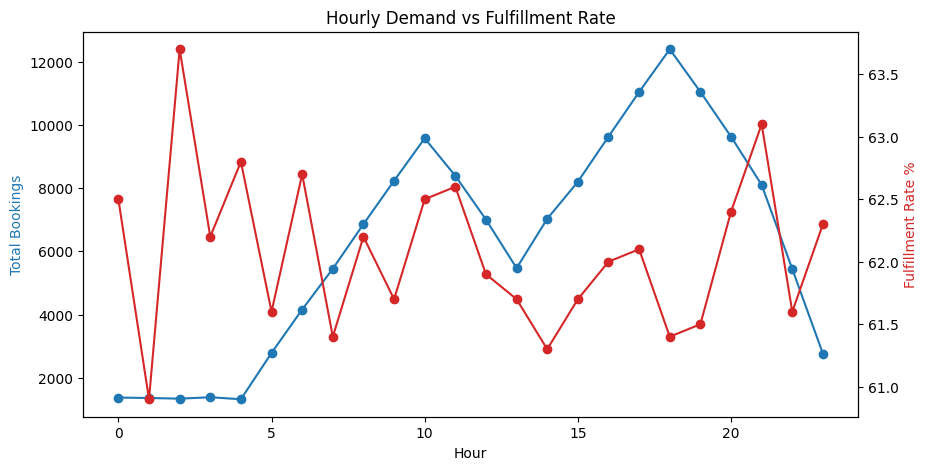

In [ ]:
import matplotlib.pyplot as plt


fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(hc['Hour'], hc['Total_Bookings'], color='tab:blue', marker='o')
ax1.set_xlabel('Hour'); ax1.set_ylabel('Total Bookings', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(hc['Hour'], hc['Fulfillment_Rate_%'], color='tab:red', marker='o')
ax2.set_ylabel('Fulfillment Rate %', color='tab:red')
plt.title('Hourly Demand vs Fulfillment Rate')
plt.show()


## Q1) Peak Ride Hours & Days

**Insight:** Demand peaks at 18:00–19:00 (12,397 and 11,047 bookings), the evening commute window, with a secondary peak at 9–11 AM (morning commute). Demand is fairly flat across days (21,200–21,644), so day-of-week is not a driver of variation, hour-of-day is. Fulfillment rate is essentially flat (~61%) across all hours, including peak hours, meaning the ~39% loss isn't a peak-hour supply crunch, it's a constant, structural problem throughout the day.

**Recommendation:** Don't deploy hour-specific surge/incentive strategies expecting to fix fulfillment — peak hours aren't worse than off-peak. Instead investigate the flat 39% non-fulfillment rate as a systemic issue (see Q3). Use the 18:00–19:00 and 9–11 AM peaks only for driver shift-scheduling/supply positioning, not for cancellation-fixing efforts.

---

## Q2) Which pickup locations generate the highest ride demand?

Business Objective: Identify high-demand zones to prioritize driver positioning and city-zone marketing spend.

In [ ]:
top_pickup = df['Pickup Location'].value_counts().head(10).reset_index()
top_pickup.columns = ['Pickup Location','Total_Bookings']

top_drop = df['Drop Location'].value_counts().head(10).reset_index()
top_drop.columns = ['Drop Location','Total_Bookings']

# Cancellation rate by pickup location, only for top 10 high-volume locations (avoid noise from low-volume locations)
top10_locs = top_pickup['Pickup Location'].tolist()
loc_status = df[df['Pickup Location'].isin(top10_locs)].groupby(['Pickup Location','Booking Status']).size().unstack(fill_value=0)
loc_status['Total'] = loc_status.sum(axis=1)
loc_status['Cancel_Rate_%'] = ((loc_status.get('Cancelled by Customer',0) + loc_status.get('Cancelled by Driver',0)) / loc_status['Total'] * 100).round(1)
loc_status.sort_values('Cancel_Rate_%', ascending=False)

Booking Status,Cancelled by Customer,Cancelled by Driver,Completed,Incomplete,No Driver Found,Total,Cancel_Rate_%
Pickup Location,,,,,,,
Pragati Maidan,69,179,538,64,70,920,27.0
Saket,70,179,557,60,65,931,26.7
AIIMS,60,176,562,57,63,918,25.7
Badarpur,72,159,567,61,62,921,25.1
Dwarka Sector 21,57,170,565,54,68,914,24.8
Mehrauli,59,165,574,46,71,915,24.5
Barakhamba Road,60,170,594,64,58,946,24.3
Khandsa,57,169,600,62,61,949,23.8
Pataudi Chowk,65,150,556,56,80,907,23.7


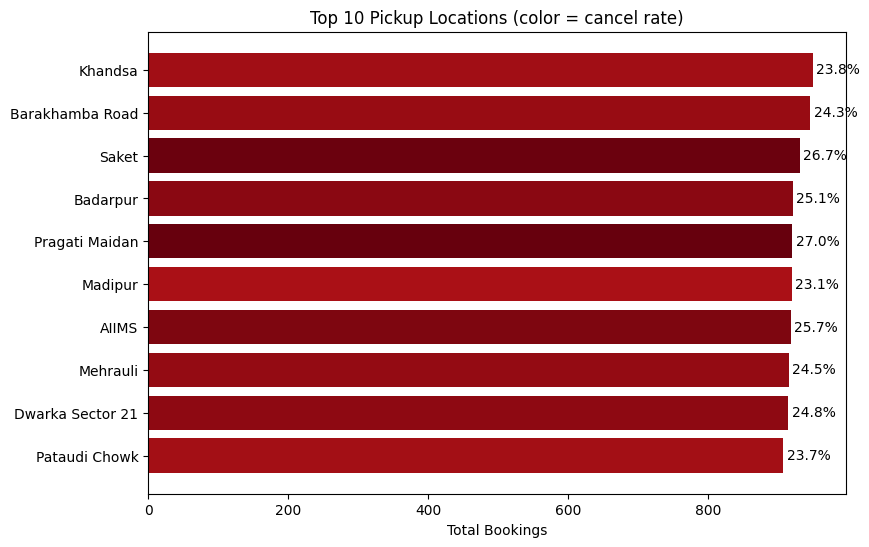

In [ ]:
#Top 10 pickup locations, color-coded by cancel rate
top10_locs = df['Pickup Location'].value_counts().head(10).index
loc = df[df['Pickup Location'].isin(top10_locs)].groupby('Pickup Location')['Booking Status'].value_counts().unstack(fill_value=0)
loc['Total'] = loc.sum(axis=1)
loc['Cancel_Rate_%'] = ((loc['Cancelled by Driver'] + loc['Cancelled by Customer']) / loc['Total'] * 100).round(1)
loc = loc.sort_values('Total', ascending=True)

fig, ax = plt.subplots(figsize=(9,6))
bars = ax.barh(loc.index, loc['Total'], color=plt.cm.Reds(loc['Cancel_Rate_%']/loc['Cancel_Rate_%'].max()))
for i,(t,c) in enumerate(zip(loc['Total'], loc['Cancel_Rate_%'])):
    ax.text(t+5, i, f'{c}%', va='center')
ax.set_xlabel('Total Bookings')
plt.title('Top 10 Pickup Locations (color = cancel rate)')
plt.show()

## Q2) Top Pickup Locations

**Insight:** Top-volume pickup locations also carry the highest cancellation rates, Pragati Maidan (27.0%), Saket (26.7%), AIIMS (25.7%), all above the platform average (~25%). Demand and cancellation risk are concentrated in the same zones, compounding revenue loss exactly where ride volume is highest.

**Recommendation:** Prioritize driver supply and quality interventions in these top 10 zones first, fixing cancellation rate here yields the largest absolute volume recovery. Flag Pragati Maidan and Saket for root-cause investigation (traffic congestion, parking/access issues) before any city-wide cancellation initiative.

---

## Q3) Cancellation Patterns

In [ ]:
total = len(df)

In [ ]:
# 1. Cancellation rate by hour
hr = df.groupby('Hour')['Booking Status'].value_counts().unstack(fill_value=0)
hr['Total'] = hr.sum(axis=1)
hr['Cancel_Rate_%'] = ((hr['Cancelled by Driver'] + hr['Cancelled by Customer']) / hr['Total'] * 100).round(1)
hr[['Total','Cancel_Rate_%']].sort_values('Cancel_Rate_%', ascending=False).head(10)

Booking Status,Total,Cancel_Rate_%
Hour,,
5,2786,26.4
14,7031,26.1
15,8202,25.7
3,1383,25.7
4,1321,25.6
22,5441,25.6
19,11047,25.5
7,5450,25.4
18,12397,25.4


In [ ]:
# 2. Cancellation rate by day
dy = df.groupby('DayOfWeek')['Booking Status'].value_counts().unstack(fill_value=0)
dy['Total'] = dy.sum(axis=1)
dy['Cancel_Rate_%'] = ((dy['Cancelled by Driver'] + dy['Cancelled by Customer']) / dy['Total'] * 100).round(1)
dy[['Total','Cancel_Rate_%']].sort_values('Cancel_Rate_%', ascending=False)

Booking Status,Total,Cancel_Rate_%
DayOfWeek,,
Monday,21644,25.7
Tuesday,21391,25.2
Friday,21397,25.0
Sunday,21398,25.0
Wednesday,21413,24.8
Saturday,21542,24.7
Thursday,21215,24.7


In [ ]:
# 3. Cancellation rate by pickup location (top 10 by volume only avoid noise)
top10_locs = df['Pickup Location'].value_counts().head(10).index
loc = df[df['Pickup Location'].isin(top10_locs)].groupby('Pickup Location')['Booking Status'].value_counts().unstack(fill_value=0)
loc['Total'] = loc.sum(axis=1)
loc['Cancel_Rate_%'] = ((loc['Cancelled by Driver'] + loc['Cancelled by Customer']) / loc['Total'] * 100).round(1)
loc[['Total','Cancel_Rate_%']].sort_values('Cancel_Rate_%', ascending=False)

Booking Status,Total,Cancel_Rate_%
Pickup Location,,
Pragati Maidan,920,27.0
Saket,931,26.7
AIIMS,918,25.7
Badarpur,921,25.1
Dwarka Sector 21,914,24.8
Mehrauli,915,24.5
Barakhamba Road,946,24.3
Khandsa,949,23.8
Pataudi Chowk,907,23.7


In [ ]:
# 4. Customer vs Driver cancellation share
print("Driver share: ", round(27000/37500*100,1), "%")
print("Customer share: ", round(10500/37500*100,1), "%")

Driver share:  72.0 %
Customer share:  28.0 %


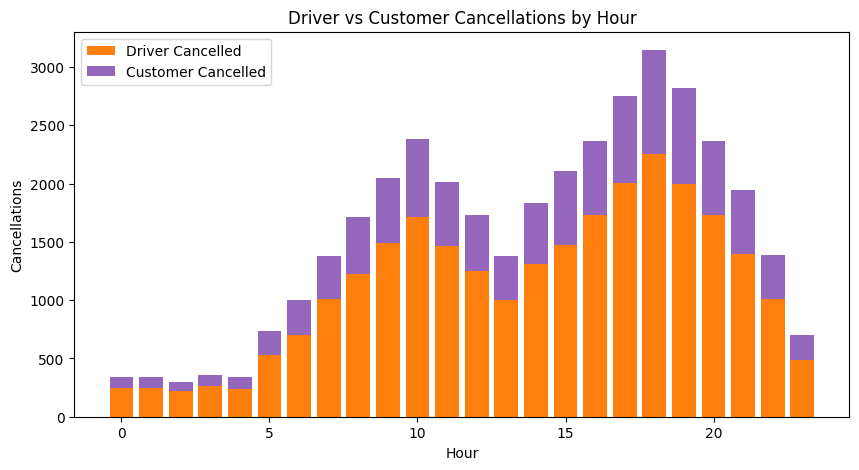

In [ ]:
#Stacked bar: Driver vs Customer cancellations by hour
hr_cancel = df.groupby('Hour')['Booking Status'].value_counts().unstack(fill_value=0)
hr_cancel = hr_cancel.sort_index()
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(hr_cancel.index, hr_cancel['Cancelled by Driver'], label='Driver Cancelled', color='tab:orange')
ax.bar(hr_cancel.index, hr_cancel['Cancelled by Customer'], bottom=hr_cancel['Cancelled by Driver'], label='Customer Cancelled', color='tab:purple')
ax.set_xlabel('Hour'); ax.set_ylabel('Cancellations')
plt.legend()
plt.title('Driver vs Customer Cancellations by Hour')
plt.show()

In [ ]:
# 5. Top reasons - customer
df['Reason for cancelling by Customer'].value_counts().head(5)

,count
Reason for cancelling by Customer,
Wrong Address,2362
Change of plans,2353
Driver is not moving towards pickup location,2335
Driver asked to cancel,2295
AC is not working,1155


In [ ]:
# 6. Top reasons - driver
df['Driver Cancellation Reason'].value_counts()

,count
Driver Cancellation Reason,
Customer related issue,6837
The customer was coughing/sick,6751
Personal & Car related issues,6726
More than permitted people in there,6686


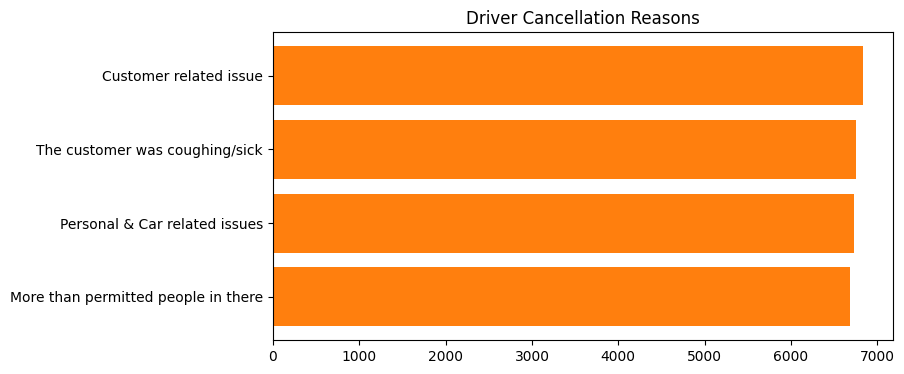

In [ ]:
#driver cancellation reasons
reasons = df['Driver Cancellation Reason'].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(8,4))
ax.barh(reasons.index, reasons.values, color='tab:orange')
plt.title('Driver Cancellation Reasons')
plt.show()

## Q3) Cancellation Patterns

**Insight:** Cancellation rate is structurally flat across hour (22–27%) and day (24.7–25.7%), there is no meaningful time-based pattern. The real driver is **who** cancels: drivers cause 72% of all cancellations vs. 28% by customers, a 2.6x imbalance. Driver reasons are dominated by soft/subjective justifications, "Customer related issue" (6,837), "customer was coughing/sick" (6,751), "Personal & car issues" (6,726), "more than permitted people" (6,686), all clustered tightly (~6,700–6,837), suggesting these may be generic/default app reasons rather than distinct root causes. Customer-side cancellations are more diagnostic: "Wrong Address" (2,362) and "Driver is not moving towards pickup" (2,335) point to navigation/ETA accuracy issues, and "Driver asked to cancel" (2,295) shows driver-initiated cancellations are sometimes mislabeled as customer cancellations.

**Recommendation:** This is a driver-supply/behavior problem, not a scheduling problem. Priority actions:
* audit driver cancellation reason categories, the near-equal distribution across 4 reasons suggests the reason field isn't capturing true causes, recommend a UX/data quality fix;
* investigate "Driver asked to cancel" appearing under customer reasons, possible process leak inflating customer cancellation stats unfairly;
* target driver-side cancellation reduction programs (ratings-linked incentives, penalty review) since fixing driver-side alone addresses 72% of the 25% total cancellation loss.

---

## Overall Insight

Of ~150K bookings, ~25% cancel, and this loss is constant across all hours and days, ruling out time-based fixes. The two real levers are **location** (top-demand zones like Pragati Maidan and Saket cancel more, concentrating risk where volume is highest) and **driver behavior** (72% of cancellations are driver-caused, nearly 3x customer-caused). The business should stop treating cancellation as a scheduling/staffing issue and treat it as a driver-quality and high-demand-zone reliability issue, fixing these two levers protects the largest share of the ~37,500 lost bookings.